First define AI topics, what entities occur mostly in AI topics

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
df_ent = pd.read_parquet('/content/drive/MyDrive/NLP Final Project/Entity Extraction/docs_with_entities_full_trf.parquet')

Mounted at /content/drive


In [ ]:
df= pd.read_parquet('/content/drive/MyDrive/NLP Final Project/entity_topic_td_summary.parquet')

In [ ]:
AI_TOPIC_IDS = [
    0,   # AI Image Generation
    11,  # ChatGPT & AI Tools
    12,  # Chinese AI & Tech Competition
    13,  # Semiconductors & GPUs
    17,  # OpenAI Governance
    18,  # AI Copyright
    28,  # Generative Video Tools
    45,  # AI Content Creation
    52,  # Elon Musk / xAI
    70,  # AI Assistants
    83,  # Voice AI
    86   # OpenAI Voice Controversy
]

In [ ]:
total_mentions = (
    df
    .groupby("entity")["n_mentions"]
    .sum()
)

In [ ]:
ai_mentions = (
    df[
        df["topic"].isin(AI_TOPIC_IDS)
    ]
    .groupby("entity")["n_mentions"]
    .sum()
)

In [ ]:
ai_exposure = (
    ai_mentions / total_mentions
).fillna(0).reset_index()

ai_exposure.columns = ["entity", "ai_exposure"]

ai_exposure.sort_values("ai_exposure", ascending=False).head(20)

,entity,ai_exposure
49,rawpixel,0.736842
38,Siri,0.422564
14,DeepSeek,0.304120
5,Apple,0.250571
48,iPhone,0.173482
47,iOS,0.133362
6,Apple Watch,0.121337
26,LinkedIn,0.115114
25,LLM,0.077318
16,FCC,0.052519


In [ ]:
MIN_MENTIONS = 10

entity_volume = total_mentions.reset_index()
entity_volume.columns = ["entity", "total_mentions"]

ai_exposure = ai_exposure.merge(entity_volume, on="entity")

ai_exposure = ai_exposure[
    ai_exposure["total_mentions"] >= MIN_MENTIONS
]

ai_exposure.sort_values("ai_exposure", ascending=False).head(20)

,entity,ai_exposure,total_mentions
49,rawpixel,0.736842,76
38,Siri,0.422564,3900
14,DeepSeek,0.304120,4199
5,Apple,0.250571,51215
48,iPhone,0.173482,20959
47,iOS,0.133362,14097
6,Apple Watch,0.121337,2662
26,LinkedIn,0.115114,10103
25,LLM,0.077318,2923
16,FCC,0.052519,5598


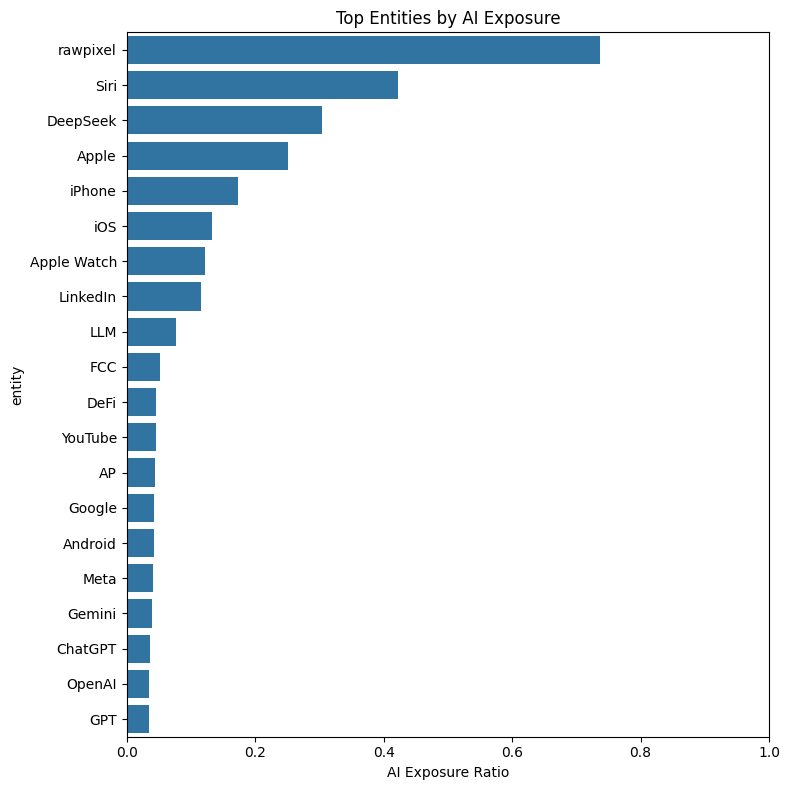

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_exposed = ai_exposure.sort_values("ai_exposure", ascending=False).head(20)

plt.figure(figsize=(8,8))
sns.barplot(
    data=top_exposed,
    y="entity",
    x="ai_exposure"
)

plt.title("Top Entities by AI Exposure")
plt.xlabel("AI Exposure Ratio")
plt.xlim(0,1)
plt.tight_layout()
plt.show()

When an entity is mentioned in AI-related contexts, is it framed positively or negatively?

In [ ]:
AI_TOPIC_IDS = [
    0, 11, 12, 13, 17, 18, 28, 45, 52, 70, 83, 86
]

ai_only = df[
    df["topic"].isin(AI_TOPIC_IDS)
].copy()

ai_td = (
    ai_only
    .groupby("entity")
    .apply(lambda x: (
        (x["mean_td_score"] * x["n_mentions"]).sum()
        / x["n_mentions"].sum()
    ))
    .reset_index(name="ai_td_score")
)

/tmp/ipykernel_693/4208027212.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (


In [ ]:
ai_volume = (
    ai_only
    .groupby("entity")["n_mentions"]
    .sum()
    .reset_index(name="ai_mentions")
)

ai_td = ai_td.merge(ai_volume, on="entity")

In [ ]:
total_mentions = (
    df
    .groupby("entity")["n_mentions"]
    .sum()
    .reset_index(name="total_mentions")
)

ai_td = ai_td.merge(total_mentions, on="entity")

In [ ]:
ai_td["ai_exposure"] = ai_td["ai_mentions"] / ai_td["total_mentions"]
ai_td.sort_values("ai_td_score", ascending=False)

,entity,ai_td_score,ai_mentions,total_mentions,ai_exposure
32,OpenAI,0.426433,4699,134434,0.034954
21,Gemini,0.359664,817,20492,0.039869
11,Claude,0.342850,126,3747,0.033627
7,Bard,0.305265,316,11432,0.027642
19,GPT-4,0.293475,163,6794,0.023992
12,Copilot,0.292762,271,9926,0.027302
10,ChatGPT,0.290430,5764,158189,0.036437
28,Meta,0.283622,670,16415,0.040816
14,DeepSeek,0.280747,1277,4199,0.304120
37,The Motley Fool,0.273701,1,2869,0.000349


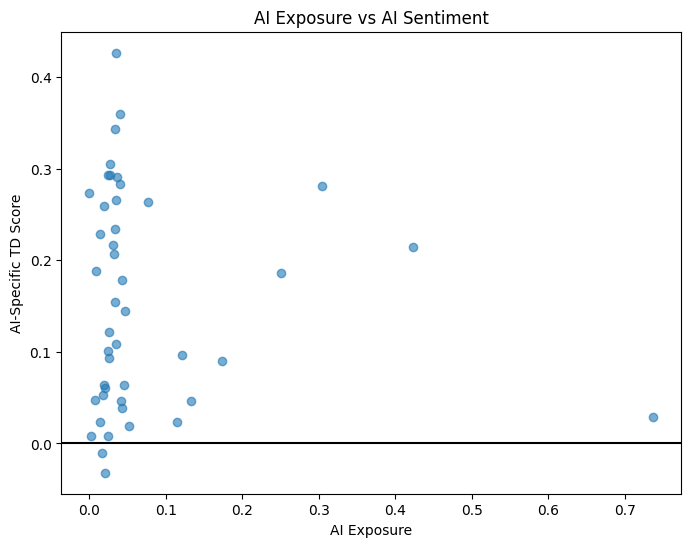

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    ai_td["ai_exposure"],
    ai_td["ai_td_score"],
    alpha=0.6
)

plt.axhline(0, color="black")
plt.xlabel("AI Exposure")
plt.ylabel("AI-Specific TD Score")
plt.title("AI Exposure vs AI Sentiment")

plt.show()

In [ ]:
exposure_threshold = ai_td["ai_exposure"].quantile(0.75)
high_exp = ai_td[ai_td["ai_exposure"] >= exposure_threshold]

print("High exposure N:", len(high_exp))
print("High exposure, ai_td_score < 0 N:", (high_exp["ai_td_score"] < 0).sum())
print("Min/median/max ai_td_score in high exposure:",
      high_exp["ai_td_score"].min(), high_exp["ai_td_score"].median(), high_exp["ai_td_score"].max())

High exposure N: 12
High exposure, ai_td_score < 0 N: 0
Min/median/max ai_td_score in high exposure: 0.018981661592914284 0.09286976711317022 0.2807469697378885


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- settings ----------
TOP_N = 50                 # number of bars to show
EXPOSURE_Q = 0.5          # high exposure = top 25%
MIN_AI_MENTIONS = 10       # stability filter (tune)
MIN_TOTAL_MENTIONS = 100   # stability filter (tune)

df = ai_td.copy()

# stability filters
df = df[(df["ai_mentions"] >= MIN_AI_MENTIONS) & (df["total_mentions"] >= MIN_TOTAL_MENTIONS)].copy()

# define "high exposure"
exposure_threshold = df["ai_exposure"].quantile(EXPOSURE_Q)
high_exp = df[df["ai_exposure"] >= exposure_threshold].copy()

print("Exposure threshold:", exposure_threshold)
print("High-exposure entities:", len(high_exp))

Exposure threshold: 0.033515677724203635
High-exposure entities: 21


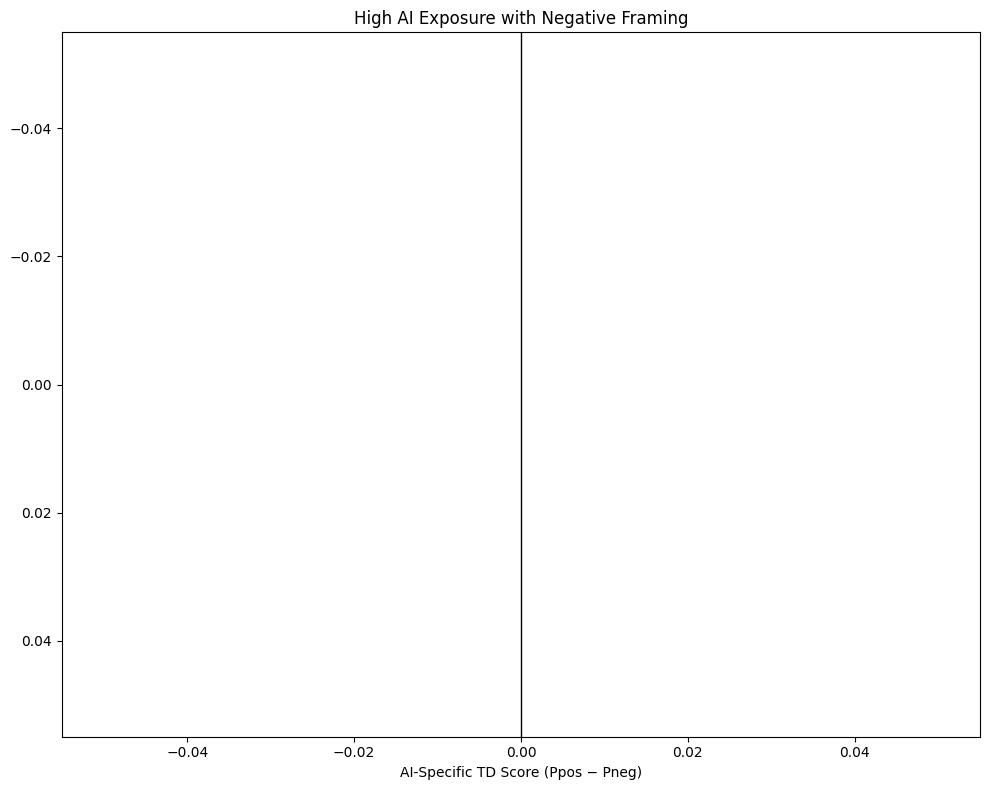

In [ ]:
neg = (
    high_exp[high_exp["ai_td_score"] < 0]
    .sort_values("ai_td_score")          # most negative first
    .head(TOP_N)
    .copy()
)

plt.figure(figsize=(10, 8))
plt.barh(neg["entity"], neg["ai_td_score"])
plt.axvline(0, color="black", linewidth=1)
plt.title("High AI Exposure with Negative Framing")
plt.xlabel("AI-Specific TD Score (Ppos − Pneg)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

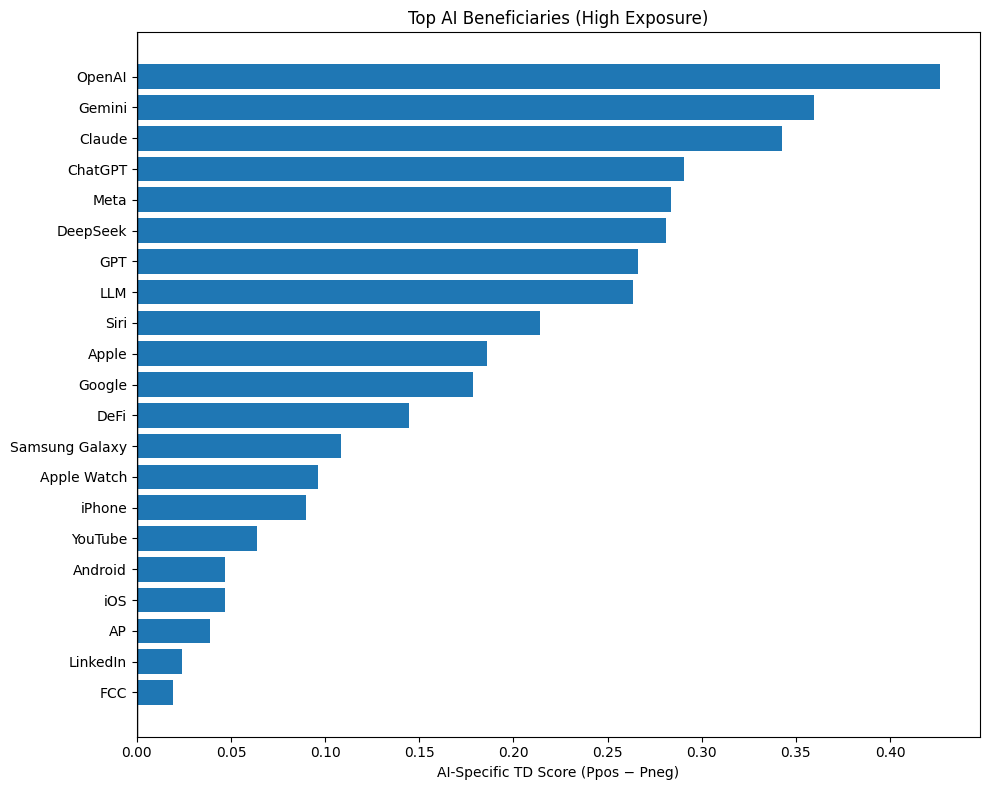

In [ ]:
ben = (
    high_exp[high_exp["ai_td_score"] > 0]
    .sort_values("ai_td_score", ascending=False)   # most positive first
    .head(TOP_N)
    .copy()
)

plt.figure(figsize=(10, 8))
plt.barh(ben["entity"], ben["ai_td_score"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Top AI Beneficiaries (High Exposure)")
plt.xlabel("AI-Specific TD Score (Ppos − Pneg)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
overall_td = (
    df
    .groupby("entity")
    .apply(lambda x: (x["mean_td_score"] * x["n_mentions"]).sum() / x["n_mentions"].sum())
    .reset_index(name="overall_td_score")
)

compare = ai_td.merge(overall_td, on="entity")

plt.figure(figsize=(8,6))
plt.scatter(compare["overall_td_score"], compare["ai_td_score"], alpha=0.7)

plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.xlabel("Overall TD Score")
plt.ylabel("AI-Specific TD Score")
plt.title("Overall Tone vs AI-Specific Tone")
plt.show()

KeyError: 'mean_td_score'

In [ ]:
df.columns

Index(['entity', 'ai_td_score', 'ai_mentions', 'total_mentions',
       'ai_exposure'],
      dtype='object')

In [ ]:
df_ent = pd.read_parquet('/content/drive/MyDrive/NLP Final Project/Entity Extraction/docs_with_entities_full_trf.parquet')

In [ ]:
import numpy as np
import pandas as pd
import ast

def flatten_entities(x):
    """
    Return a flat Python list of string entities.
    Handles: NaN/None, list/tuple, np.ndarray (possibly nested), and stringified lists.
    """
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    # If stored as string like "['Google','OpenAI']"
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "nan":
            return []
        try:
            v = ast.literal_eval(s)
            x = v
        except Exception:
            return [s]

    out = []
    def rec(y):
        if y is None or (isinstance(y, float) and pd.isna(y)):
            return
        if isinstance(y, str):
            ys = y.strip()
            if ys:
                out.append(ys)
            return
        if isinstance(y, (np.ndarray, list, tuple)):
            for z in list(y):
                rec(z)
            return
        out.append(str(y))

    if isinstance(x, (np.ndarray, list, tuple)):
        rec(x)
        return out

    return [str(x)]

In [ ]:
df_1 = df_ent.copy()

# parse date
df_1["date"] = pd.to_datetime(df_1["date"], errors="coerce")
df_1 = df_1.dropna(subset=["date"])

# flatten org/tech entity lists
df_1["org_entities"]  = df_1["org_entities"].apply(flatten_entities)
df_1["tech_entities"] = df_1["tech_entities"].apply(flatten_entities)

# combine
df_1["all_entities"] = df_1["org_entities"] + df_1["tech_entities"]

In [ ]:
df_exp = (
    df_1[["date", "topic", "topic_name", "all_entities"]]
    .explode("all_entities")
    .dropna(subset=["all_entities"])
    .rename(columns={"all_entities": "entity"})
)

# ensure entity is a string scalar
df_exp["entity"] = df_exp["entity"].astype(str)

# optional: drop empty strings
df_exp = df_exp[df_exp["entity"].str.len() > 0]

print("Exploded rows:", len(df_exp))
print(df_exp.head())

Exploded rows: 6724326
        date  topic topic_name                 entity
0 2025-06-23     68       None                    BAD
0 2025-06-23     68       None                    BAD
0 2025-06-23     68       None        Bad Idea AI?The
0 2025-06-23     68       None            Bad Idea AI
0 2025-06-23     68       None  Bad Idea AI?Currently


In [ ]:
print(df_exp["entity"].apply(type).value_counts().head())

entity
<class 'str'>    6724326
Name: count, dtype: int64


In [ ]:
AI_TOPIC_IDS = [0, 11, 12, 13, 17, 18, 28, 45, 52, 70, 83, 86]
df_exp[df_exp["topic"].isin(AI_TOPIC_IDS)][["topic","topic_name"]].drop_duplicates().sort_values("topic").head(30)

,topic,topic_name
22,0,AI Image Generation & Creative Tools
137,11,ChatGPT & AI Tools
180,12,Chinese AI & Tech Competition
62,13,Semiconductors & GPUs
77,17,OpenAI Leadership & Governance
411,18,AI Copyright & Legal Disputes
219,28,None
827,45,None
49,52,None
114,70,None


In [ ]:
FREQ = "M"  # monthly; change to "W" for weekly

# total mentions per entity-month (doc-level mentions, since entity lists are per doc)
entity_total = (
    df_exp
    .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
    .size()
    .reset_index(name="total_mentions")
)

# AI mentions per entity-month
entity_ai = (
    df_exp[df_exp["topic"].isin(AI_TOPIC_IDS)]
    .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
    .size()
    .reset_index(name="ai_mentions")
)

# merge + share
entity_time = entity_total.merge(entity_ai, on=["entity","date"], how="left")
entity_time["ai_mentions"] = entity_time["ai_mentions"].fillna(0).astype(int)
entity_time["ai_share"] = entity_time["ai_mentions"] / entity_time["total_mentions"]

entity_time.head()

/tmp/ipykernel_693/3025440358.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
/tmp/ipykernel_693/3025440358.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])


,entity,date,total_mentions,ai_mentions,ai_share
0,!,2022-03-31,2,0,0.0
1,!,2022-06-30,1,0,0.0
2,!,2022-12-31,1,0,0.0
3,!,2023-03-31,6,0,0.0
4,!,2023-04-30,1,0,0.0


In [ ]:
def slope_ai_share(g):
    g = g.sort_values("date")
    if len(g) < 6:   # require enough time points to be meaningful
        return np.nan
    x = np.arange(len(g), dtype=float)
    y = g["ai_share"].to_numpy(dtype=float)
    return np.polyfit(x, y, 1)[0]

entity_accel = (
    entity_time
    .groupby("entity")
    .apply(slope_ai_share)
    .reset_index(name="ai_acceleration")
    .dropna()
)

entity_accel.sort_values("ai_acceleration", ascending=False).head(20)

/tmp/ipykernel_693/1262118997.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ai_share)


,entity,ai_acceleration
276117,Mitsubishi Electric Corp.,0.247619
173709,Gainey McKenna & Egleston,0.234286
452337,Versal,0.228571
320440,Pennsylvania News 27,0.228571
296498,Nightfall,0.228571
98898,CisionOne,0.228571
401385,TMDX,0.228571
540138,the U.S. Cybersecurity and Infrastructure Secu...,0.228571
390529,State Bank,0.228571
183303,GmbH,0.228571


In [ ]:
ai_impact = ai_td.merge(entity_accel, on="entity", how="left")
ai_impact.sort_values("ai_acceleration", ascending=False).head(20)

,entity,ai_td_score,ai_mentions,total_mentions,ai_exposure,ai_acceleration
35,Siri,0.214099,1648,3900,0.422564,0.013148
14,DeepSeek,0.280747,1277,4199,0.304120,0.012841
27,MEXC,0.007813,22,916,0.024017,0.005158
43,iPhone,0.089663,3636,20959,0.173482,0.004387
5,Apple,0.185789,12833,51215,0.250571,0.004166
42,iOS,0.046599,1880,14097,0.133362,0.003845
41,cryptocurrency,0.023649,92,6565,0.014014,0.002902
25,LLM,0.263608,226,2923,0.077318,0.002235
13,DeFi,0.144481,30,649,0.046225,0.001898
21,Gemini,0.359664,817,20492,0.039869,0.001237


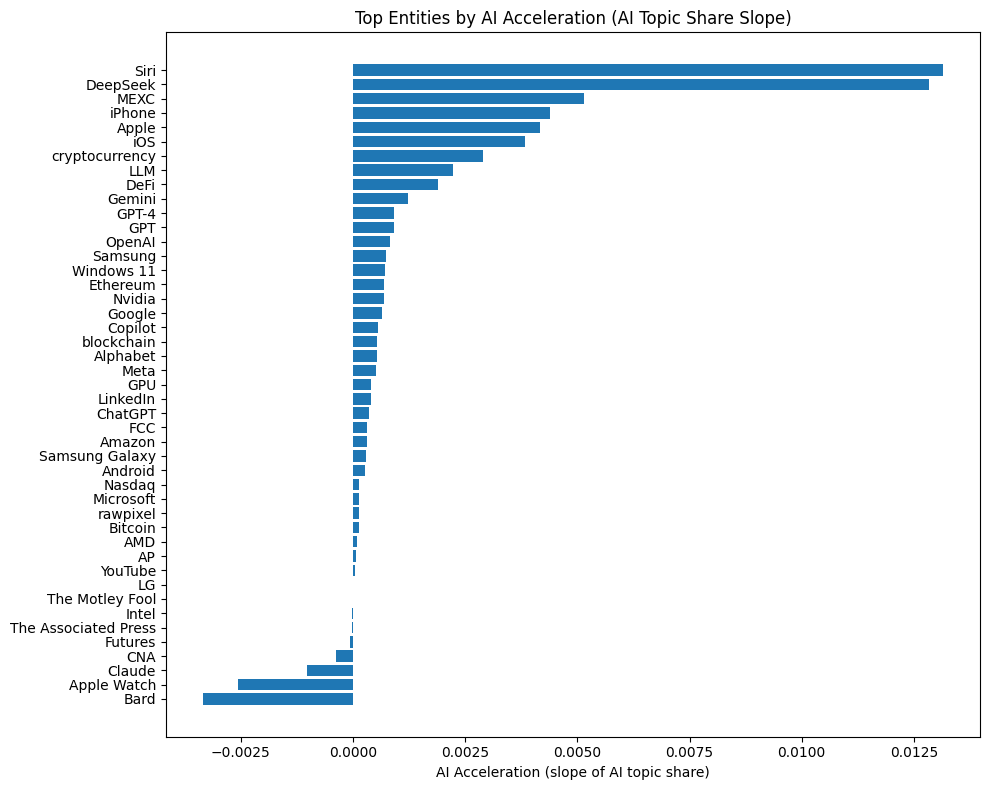

In [ ]:
import matplotlib.pyplot as plt

topN = 100
top_acc = ai_impact.dropna(subset=["ai_acceleration"]).sort_values("ai_acceleration", ascending=False).head(topN)

plt.figure(figsize=(10, 8))
plt.barh(top_acc["entity"], top_acc["ai_acceleration"])
plt.title("Top Entities by AI Acceleration (AI Topic Share Slope)")
plt.xlabel("AI Acceleration (slope of AI topic share)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

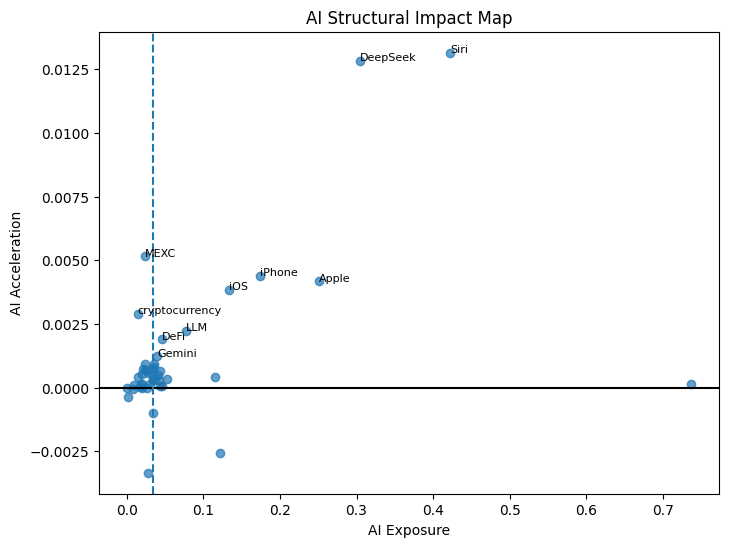

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    ai_impact["ai_exposure"],
    ai_impact["ai_acceleration"],
    alpha=0.7
)

plt.axhline(0, color="black")
plt.axvline(ai_impact["ai_exposure"].median(), linestyle="--")

plt.xlabel("AI Exposure")
plt.ylabel("AI Acceleration")
plt.title("AI Structural Impact Map")

# Label top accelerators
top_label = ai_impact.sort_values("ai_acceleration", ascending=False).head(10)
for _, row in top_label.iterrows():
    plt.text(row["ai_exposure"], row["ai_acceleration"], row["entity"], fontsize=8)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

AI_TOPIC_IDS = [0, 11, 12, 13, 17, 18, 28, 45, 52, 70, 83, 86]
TOP_E = 1000  # adjust
top_entities = df_exp["entity"].value_counts().head(TOP_E).index
df_net = df_exp[df_exp["entity"].isin(top_entities)].copy()
df_net_ai = df_net[df_net["topic"].isin(AI_TOPIC_IDS)].copy()

In [ ]:
edges_et = (
    df_net_ai
    .groupby(["entity", "topic", "topic_name"])
    .size()
    .reset_index(name="w")
)

edges_et.head()

,entity,topic,topic_name,w
0,-,0,AI Image Generation & Creative Tools,1
1,-,11,ChatGPT & AI Tools,13
2,-,12,Chinese AI & Tech Competition,11
3,-,13,Semiconductors & GPUs,30
4,-,17,OpenAI Leadership & Governance,3


In [ ]:
B = nx.Graph()

# Add entity nodes
B.add_nodes_from(edges_et["entity"].unique().tolist(), bipartite="entity")

# Add topic nodes (use a prefixed id to avoid collision with entity names)
topic_nodes = ("T_" + edges_et["topic"].astype(str) + " | " + edges_et["topic_name"].astype(str)).unique().tolist()
B.add_nodes_from(topic_nodes, bipartite="topic")

# Add weighted edges
for r in edges_et.itertuples(index=False):
    e = r.entity
    tnode = f"T_{int(r.topic)} | {r.topic_name}"
    B.add_edge(e, tnode, weight=int(r.w))

In [ ]:
entity_strength = {}
for n, attr in B.nodes(data=True):
    if attr.get("bipartite") == "entity":
        entity_strength[n] = sum(d.get("weight", 1) for _, _, d in B.edges(n, data=True))

cent_strength = (
    pd.Series(entity_strength, name="strength")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "entity"})
)

cent_strength.head(20)

,entity,strength
0,Apple,14963
1,Rawpixel Ltd.,13905
2,DeepSeek,10223
3,ChatGPT,8517
4,rawpixel,7966
5,OpenAI,7897
6,iPhone,7804
7,Siri,4661
8,Google,3303
9,Spotify,3218


In [ ]:
pr = nx.pagerank(B, weight="weight")
entity_pagerank = {n: s for n, s in pr.items() if B.nodes[n].get("bipartite") == "entity"}

cent_pagerank = (
    pd.Series(entity_pagerank, name="pagerank")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "entity"})
)

cent_pagerank.head(20)

,entity,pagerank
0,Apple,0.036335
1,DeepSeek,0.029365
2,ChatGPT,0.024279
3,OpenAI,0.021990
4,iPhone,0.019272
5,Rawpixel Ltd.,0.018729
6,Spotify,0.013089
7,Siri,0.011323
8,rawpixel,0.010801
9,Google,0.009585


In [ ]:
TOP_PER_TOPIC = 500   # cap per topic to control explosion
topic_groups = (
    df_net_ai
    .groupby(["topic", "topic_name"])["entity"]
    .value_counts()
    .rename("cnt")
    .reset_index()
)

# Keep top entities per topic
topic_groups = topic_groups.sort_values(["topic", "cnt"], ascending=[True, False])
topic_groups["rank_in_topic"] = topic_groups.groupby("topic").cumcount() + 1
topic_groups = topic_groups[topic_groups["rank_in_topic"] <= TOP_PER_TOPIC]

In [ ]:
from itertools import combinations
from collections import defaultdict

edge_w = defaultdict(float)

for (tid, tname), g in topic_groups.groupby(["topic", "topic_name"]):
    ents = g["entity"].tolist()
    cnts = g["cnt"].tolist()
    cnt_map = dict(zip(ents, cnts))

    # add edges for all pairs in this topic (bounded by TOP_PER_TOPIC)
    for a, b in combinations(ents, 2):
        # conservative weight: min(counts) (robust to huge hubs)
        edge_w[(a, b)] += float(min(cnt_map[a], cnt_map[b]))

In [ ]:
G = nx.Graph()
for (a, b), w in edge_w.items():
    if w > 0:
        G.add_edge(a, b, weight=w)

print("Entity-Entity nodes:", G.number_of_nodes())
print("Entity-Entity edges:", G.number_of_edges())

Entity-Entity nodes: 755
Entity-Entity edges: 247226


In [ ]:
# Weighted degree (strength)
deg_strength = dict(G.degree(weight="weight"))
cent_deg = (
    pd.Series(deg_strength, name="strength")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "entity"})
)

# PageRank (weighted)
pr2 = nx.pagerank(G, weight="weight")
cent_pr2 = (
    pd.Series(pr2, name="pagerank")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "entity"})
)

cent_deg.head(20), cent_pr2.head(20)

(       entity  strength
 0     ChatGPT   80304.0
 1      OpenAI   68786.0
 2      Google   60976.0
 3      iPhone   51262.0
 4      Nvidia   47367.0
 5   Microsoft   46172.0
 6       Apple   45057.0
 7      Gemini   40524.0
 8         iOS   40366.0
 9        Siri   39287.0
 10    Android   38800.0
 11       Meta   37793.0
 12     Amazon   34816.0
 13   LinkedIn   34428.0
 14        LLM   30786.0
 15       CNBC   30192.0
 16    Samsung   30079.0
 17      Intel   29898.0
 18        GPT   29780.0
 19     Claude   29666.0,
        entity  pagerank
 0     ChatGPT  0.010687
 1      OpenAI  0.009279
 2      Google  0.008323
 3      iPhone  0.007023
 4      Nvidia  0.006630
 5   Microsoft  0.006550
 6       Apple  0.006250
 7      Gemini  0.005754
 8         iOS  0.005637
 9     Android  0.005499
 10       Meta  0.005403
 11       Siri  0.005229
 12     Amazon  0.005109
 13   LinkedIn  0.005047
 14        LLM  0.004536
 15      Intel  0.004471
 16        GPT  0.004435
 17       CNBC  0.004428

In [ ]:
# take largest connected component for betweenness
largest_cc = max(nx.connected_components(G), key=len)
Gcc = G.subgraph(largest_cc).copy()

# if too slow, reduce TOP_E or TOP_PER_TOPIC
btw = nx.betweenness_centrality(Gcc, k=min(300, len(Gcc)), seed=42, weight="weight")  # approximate
cent_btw = (
    pd.Series(btw, name="betweenness")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "entity"})
)

cent_btw.head(20)

,entity,betweenness
0,HT Digital Streams Limited,0.032151
1,Cox Media Group Television,0.032044
2,MAHINDRA,0.032044
3,Coursera,0.027173
4,HubSpot,0.026003
5,ESA,0.023961
6,DeepSeek,0.017640
7,SAS,0.014845
8,Enterprise,0.014845
9,Zoho,0.014845


Strength: “most connected/hub entities in AI ecosystem”

PageRank: “influential entities connected to other influential ones”

Betweenness: “bridges between AI subdomains (chips ↔ tools ↔ regulation, etc.)”

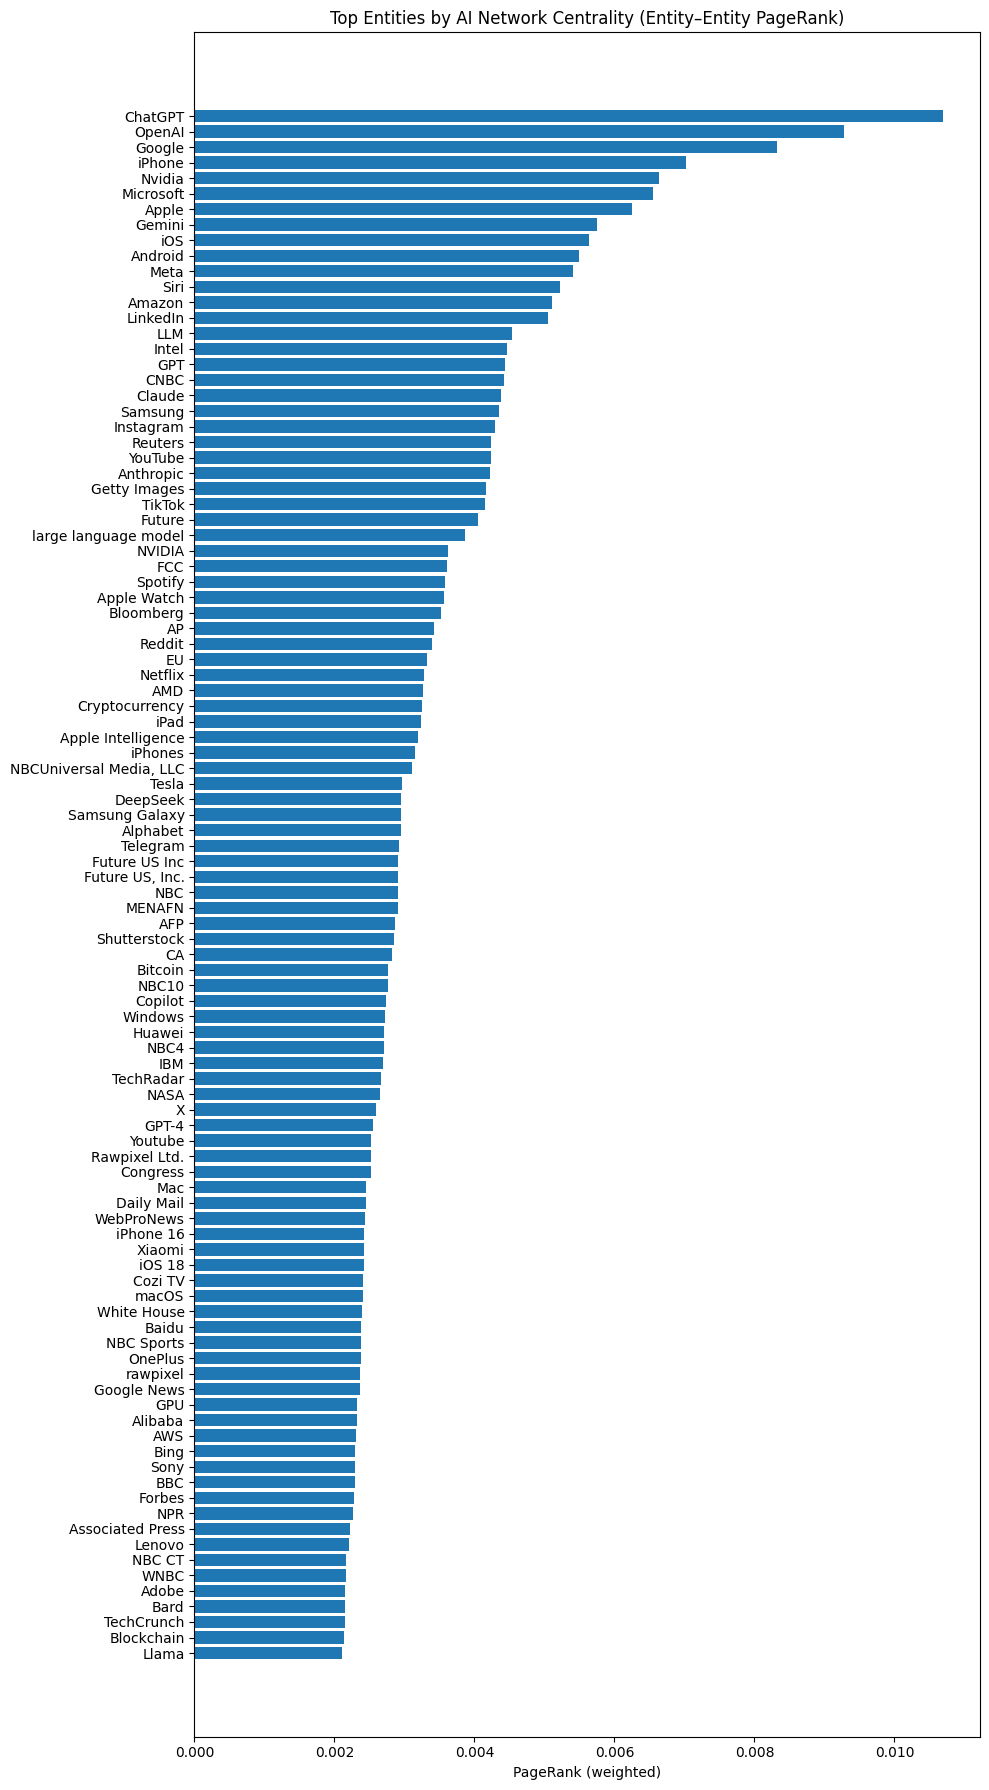

In [ ]:
import matplotlib.pyplot as plt

TOPN = 100
top_cent = cent_pr2.head(TOPN).sort_values("pagerank")

plt.figure(figsize=(10, 18))
plt.barh(top_cent["entity"], top_cent["pagerank"])
plt.title("Top Entities by AI Network Centrality (Entity–Entity PageRank)")
plt.xlabel("PageRank (weighted)")
plt.tight_layout()
plt.show()

In [ ]:
ai_impact2 = ai_impact.merge(
    cent_pr2.rename(columns={"pagerank": "ai_network_pagerank"}),
    on="entity",
    how="left"
)

ai_impact2["ai_network_pagerank"] = ai_impact2["ai_network_pagerank"].fillna(0)
ai_impact2.sort_values("ai_network_pagerank", ascending=False).head(20)

,entity,ai_td_score,ai_mentions,total_mentions,ai_exposure,ai_acceleration,ai_network_pagerank
10,ChatGPT,0.290430,5764,158189,0.036437,0.000366,0.010687
32,OpenAI,0.426433,4699,134434,0.034954,0.000826,0.009279
22,Google,0.178709,5540,128712,0.043042,0.000641,0.008323
43,iPhone,0.089663,3636,20959,0.173482,0.004387,0.007023
31,Nvidia,0.092992,1425,56364,0.025282,0.000696,0.006630
29,Microsoft,0.216330,2744,89593,0.030627,0.000132,0.006550
5,Apple,0.185789,12833,51215,0.250571,0.004166,0.006250
21,Gemini,0.359664,817,20492,0.039869,0.001237,0.005754
42,iOS,0.046599,1880,14097,0.133362,0.003845,0.005637
4,Android,0.046817,952,22595,0.042133,0.000279,0.005499


ai_exposure → structural linkage to AI topics

ai_acceleration → increasing AI relevance over time

ai_network_pagerank → ecosystem centrality

ai_td_score → narrative direction

In [ ]:
ai_impact2.sort_values("ai_network_pagerank", ascending=False).head(500)[["entity","ai_mentions","total_mentions"]]

,entity,ai_mentions,total_mentions
10,ChatGPT,5764,158189
32,OpenAI,4699,134434
22,Google,5540,128712
43,iPhone,3636,20959
31,Nvidia,1425,56364
29,Microsoft,2744,89593
5,Apple,12833,51215
21,Gemini,817,20492
42,iOS,1880,14097
4,Android,952,22595


In [ ]:
df_org = pd.read_csv('/content/drive/MyDrive/NLP Final Project/Entity Extraction/top_orgs_by_topic_full_trf.csv')
df_tech = pd.read_csv('/content/drive/MyDrive/NLP Final Project/Entity Extraction/top_tech_by_topic_full_trf.csv')

In [ ]:
df_org['entity'].value_counts().head(100).index

Index(['Google', 'Microsoft', 'OpenAI', 'ChatGPT', 'Apple', 'Amazon', 'Meta',
       'LinkedIn', 'Nvidia', 'YouTube', 'AP', 'FCC', 'Reuters',
       'Gray Media Group', 'Samsung', 'Instagram', 'Anthropic', 'CNBC',
       'Getty Images', 'The Associated Press', 'PRNewswire', 'IBM', 'Intel',
       'NPR', 'TikTok', 'Tesla', 'NVIDIA', 'Reddit', 'Associated Press',
       'Google Play', 'Future', 'AMD', 'EU', 'Alphabet', 'Nexstar Media Inc.',
       'TechRepublic', 'AWS', 'Congress', 'Nexstar', 'Youtube', 'MEXC', 'SEC',
       'Netflix', 'Bloomberg', 'Android', 'Bing', 'Gray Media Group, Inc.',
       'LG', 'Qualcomm', 'NewsNation', 'UN', 'NASDAQ', 'DeepMind', 'X',
       'Telegram', 'Oracle', 'Cisco', 'AFP', 'Huawei', 'Google Cloud', 'FDA',
       'European Union', 'Windows', 'SoftBank', 'MarketBeat', 'youtube', 'FTC',
       'SpaceX', 'xAI', 'Klarna', 'Sports Illustrated', 'NPR News', 'PBS',
       'OnePlus', 'Cloudflare', 'White House', 'Senate', 'FBI', 'Sony',
       'Salesforce', 'Sno

In [ ]:
df_tech['entity'].value_counts().head(100).index

Index(['ChatGPT', 'OpenAI', 'Android', 'iPhone', 'Gemini', 'Nvidia', 'GPT',
       'iOS', 'LLM', 'Claude', 'Intel', 'GPT-4', 'DeepSeek', 'Bitcoin',
       'Blockchain', 'NVIDIA', 'Siri', 'Bard', 'Copilot', 'AMD',
       'large language model', 'GPU', 'blockchain', 'Cryptocurrency',
       'cryptocurrency', 'Bing', 'Spotify', 'TikTok', 'Ethereum', 'Alexa',
       'Azure', 'Generative AI', 'Apple Watch', 'Samsung Galaxy', 'RTX',
       'Midjourney', 'DeFi', 'Futures', 'Stable Diffusion', 'Grok', 'Edge',
       'H100', 'Pixel', 'DALL-E', 'iPad', 'Windows 11', 'Sora', 'Consent', 'X',
       'Excel', 'BLOX Content Management System', 'Ernie Bot', 'Chrome',
       'bitcoin', 'futures', 'iPhones', 'Meta AI', 'Joy', 'Ransomware',
       'Vertex AI', 'Mistral', 'SOC', 'phishing', 'Transformer', 'RAG',
       'Python', 'Agentic AI', 'PS5', 'openai', 'A100', 'SoC', 'ChatGpt',
       'Windows', 'Gmail', 'Word', 'IPhone', 'ChatGPT Plus', 'Google Cloud',
       'Deepseek', 'Java', 'iphone', 'BigQuer

In [ ]:
industry_map = {

# 1️⃣ AI Labs
"OpenAI": "AI Labs & Foundation Models",
"Anthropic": "AI Labs & Foundation Models",
"DeepMind": "AI Labs & Foundation Models",
"xAI": "AI Labs & Foundation Models",
"DeepSeek": "AI Labs & Foundation Models",

# 2️⃣ Semiconductors
"Nvidia": "Semiconductors & Compute",
"NVIDIA": "Semiconductors & Compute",
"NVDA": "Semiconductors & Compute",
"AMD": "Semiconductors & Compute",
"Intel": "Semiconductors & Compute",
"Qualcomm": "Semiconductors & Compute",

# 3️⃣ Cloud & Enterprise
"AWS": "Cloud & Enterprise Software",
"Google Cloud": "Cloud & Enterprise Software",
"Oracle": "Cloud & Enterprise Software",
"Cisco": "Cloud & Enterprise Software",
"Snowflake": "Cloud & Enterprise Software",
"Salesforce": "Cloud & Enterprise Software",
"IBM": "Cloud & Enterprise Software",
"Cloudflare": "Cloud & Enterprise Software",

# 4️⃣ Big Tech Platforms
"Google": "Big Tech Consumer Platforms",
"Alphabet": "Big Tech Consumer Platforms",
"Microsoft": "Big Tech Consumer Platforms",
"Meta": "Big Tech Consumer Platforms",
"Amazon": "Big Tech Consumer Platforms",
"Apple": "Big Tech Consumer Platforms",

# 5️⃣ Devices & OS
"Samsung": "Consumer Devices & OS",
"LG": "Consumer Devices & OS",
"OnePlus": "Consumer Devices & OS",
"Lenovo": "Consumer Devices & OS",
"Sony": "Consumer Devices & OS",
"Tesla": "Automotive & Robotics",

# 6️⃣ Digital Media
"YouTube": "Digital Media & Journalism",
"Youtube": "Digital Media & Journalism",
"youtube": "Digital Media & Journalism",
"Reuters": "Digital Media & Journalism",
"Associated Press": "Digital Media & Journalism",
"The Associated Press": "Digital Media & Journalism",
"AP": "Digital Media & Journalism",
"NPR": "Digital Media & Journalism",
"NPR News": "Digital Media & Journalism",
"CNBC": "Digital Media & Journalism",
"Bloomberg": "Digital Media & Journalism",
"AFP": "Digital Media & Journalism",
"ABC News": "Digital Media & Journalism",
"Sports Illustrated": "Digital Media & Journalism",
"NewsNation": "Digital Media & Journalism",
"Nexstar": "Digital Media & Journalism",
"Nexstar Media Inc.": "Digital Media & Journalism",
"Gray Media Group": "Digital Media & Journalism",
"Gray Media Group, Inc.": "Digital Media & Journalism",
"Cox Media Group": "Digital Media & Journalism",

# 7️⃣ Finance & Crypto
"MEXC": "Financial Markets & Crypto",
"NASDAQ": "Financial Markets & Crypto",
"Nasdaq": "Financial Markets & Crypto",
"NYSE": "Financial Markets & Crypto",
"SEC": "Financial Markets & Crypto",
"Klarna": "Financial Markets & Crypto",
"Solana": "Financial Markets & Crypto",

# 8️⃣ Cybersecurity
"FBI": "Government & Regulation",
"FTC": "Government & Regulation",
"FDA": "Government & Regulation",
"FCC": "Government & Regulation",
"EU": "Government & Regulation",
"European Union": "Government & Regulation",
"White House": "Government & Regulation",
"Congress": "Government & Regulation",
"Senate": "Government & Regulation",
"Parliament": "Government & Regulation",
"UN": "Government & Regulation",

# 9️⃣ Retail
"Walmart": "Retail & E-Commerce",

# 🔟 Social Platforms
"Instagram": "Big Tech Consumer Platforms",
"LinkedIn": "Big Tech Consumer Platforms",
"Reddit": "Big Tech Consumer Platforms",
"Telegram": "Big Tech Consumer Platforms",
"X": "Big Tech Consumer Platforms",
"TikTok": "Big Tech Consumer Platforms",

# Misc
"Getty Images": "Digital Media & Journalism",
"Gartner": "Cloud & Enterprise Software",
"Future": "Digital Media & Journalism",
"ScienceDaily": "Digital Media & Journalism",
"MarketBeat": "Digital Media & Journalism",
"EA": "Digital Media & Journalism",
"Slack": "Cloud & Enterprise Software",
"Alibaba": "Big Tech Consumer Platforms",
"SoftBank": "Financial Markets & Crypto",
"FAANG": "Big Tech Consumer Platforms"
}

tech_category_map = {

# Foundation Models
"ChatGPT": "Foundation Models",
"GPT": "Foundation Models",
"GPT-4": "Foundation Models",
"Claude": "Foundation Models",
"Gemini": "Foundation Models",
"Bard": "Foundation Models",
"DeepSeek": "Foundation Models",
"Ernie Bot": "Foundation Models",
"Mistral": "Foundation Models",

# AI Infrastructure
"GPU": "AI Infrastructure",
"H100": "AI Infrastructure",
"A100": "AI Infrastructure",
"RTX": "AI Infrastructure",
"TensorFlow": "AI Infrastructure",

# Consumer Devices
"iPhone": "Consumer Device",
"iOS": "Operating System",
"Android": "Operating System",
"Windows": "Operating System",
"Windows 11": "Operating System",
"Pixel": "Consumer Device",
"Apple Watch": "Consumer Device",
"Samsung Galaxy": "Consumer Device",

# Crypto
"Bitcoin": "Crypto Asset",
"Ethereum": "Crypto Asset",
"Blockchain": "Blockchain",
"DeFi": "Crypto Asset",
"Cryptocurrency": "Crypto Asset",

# Enterprise AI
"Copilot": "Enterprise AI",
"Azure": "Cloud AI",
"Vertex AI": "Cloud AI",
"BigQuery": "Cloud AI",
"Generative AI": "AI Concept",

# Cybersecurity
"Ransomware": "Cybersecurity",
"phishing": "Cybersecurity",
"SOC": "Cybersecurity",

# Programming
"Python": "Programming Language",
"Java": "Programming Language",
"SQL": "Programming Language"
}

In [ ]:
ai_impact2

In [ ]:
ai_impact2["industry"] = ai_impact2["entity"].map(industry_map)
ai_impact2["industry"] = ai_impact2["industry"].fillna("Other / Misc")

In [ ]:
industry_impact = (
    ai_impact2
    .groupby("industry")
    .agg({
        "ai_exposure": "mean",
        "ai_acceleration": "mean",
        "ai_network_pagerank": "mean",
        "ai_td_score": "mean"
    })
    .reset_index()
)

In [ ]:
import numpy as np
from scipy.stats import zscore

heatmap_df = industry_impact.copy()

metrics = ["ai_exposure", "ai_acceleration", "ai_network_pagerank", "ai_td_score"]

for m in metrics:
    heatmap_df[m + "_z"] = zscore(heatmap_df[m])

heatmap_plot = heatmap_df.set_index("industry")[[m + "_z" for m in metrics]]

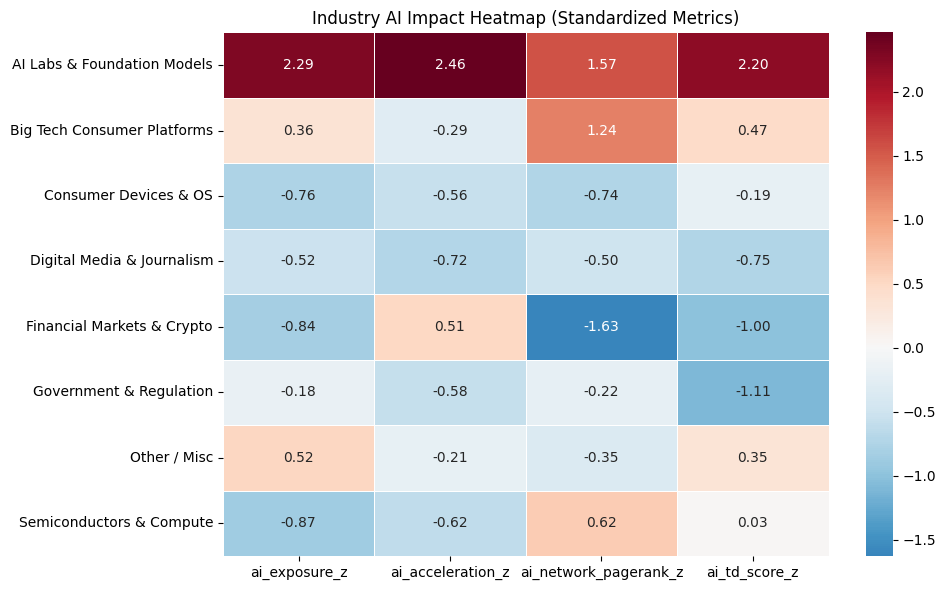

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_plot,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Industry AI Impact Heatmap (Standardized Metrics)")
plt.ylabel("")
plt.tight_layout()
plt.show()

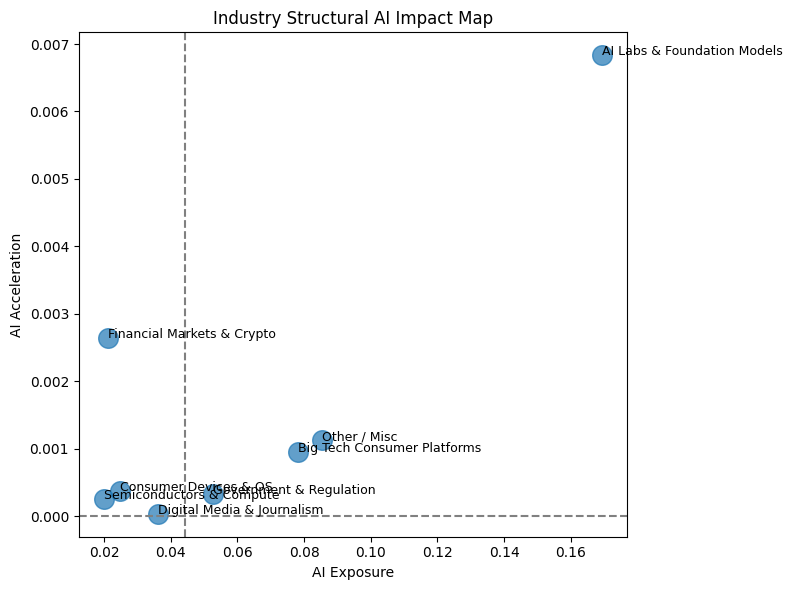

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    industry_impact["ai_exposure"],
    industry_impact["ai_acceleration"],
    s=200,
    alpha=0.7
)

plt.axvline(industry_impact["ai_exposure"].median(), linestyle="--", color="gray")
plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("AI Exposure")
plt.ylabel("AI Acceleration")
plt.title("Industry Structural AI Impact Map")

# Label points
for _, row in industry_impact.iterrows():
    plt.text(
        row["ai_exposure"],
        row["ai_acceleration"],
        row["industry"],
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
ALL_INDUSTRIES = [
    "AI Labs & Foundation Models",
    "Semiconductors & Compute",
    "Cloud & Enterprise Software",
    "Big Tech Consumer Platforms",
    "Consumer Devices & OS",
    "Digital Media & Journalism",
    "Financial Markets & Crypto",
    "Cybersecurity",
    "Telecom & Networking",
    "Government & Regulation",
    "Automotive & Robotics",
    "Retail & E-Commerce",
    "Other / Misc",
]

ai_impact2["industry"] = ai_impact2["industry"].fillna("Other / Misc")
ai_impact2["industry"] = pd.Categorical(ai_impact2["industry"], categories=ALL_INDUSTRIES, ordered=True)

In [ ]:
industry_impact = (
    ai_impact2
    .groupby("industry", observed=False)
    .agg({
        "ai_exposure": "mean",
        "ai_acceleration": "mean",
        "ai_network_pagerank": "mean",
        "ai_td_score": "mean"
    })
    .reset_index()
)

In [ ]:
from scipy.stats import zscore
import numpy as np

heatmap_df = industry_impact.copy()
metrics = ["ai_exposure","ai_acceleration","ai_network_pagerank","ai_td_score"]

# z-score only on non-null values per column
for m in metrics:
    col = heatmap_df[m]
    heatmap_df[m + "_z"] = (col - col.mean(skipna=True)) / col.std(skipna=True)

heatmap_plot = heatmap_df.set_index("industry")[[m + "_z" for m in metrics]]

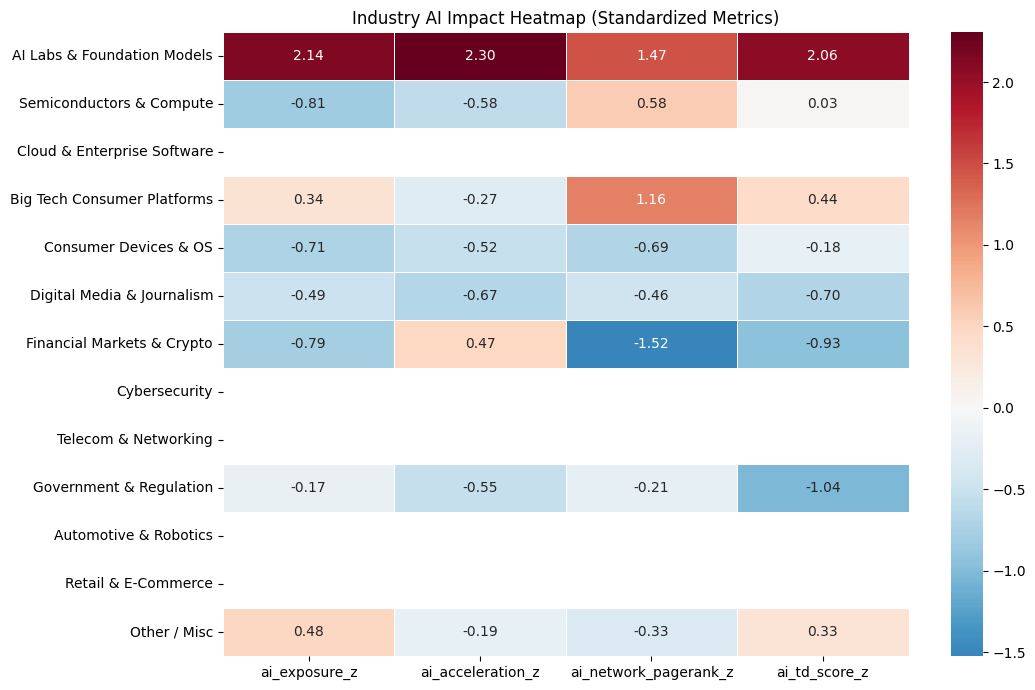

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 7))
sns.heatmap(
    heatmap_plot,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=heatmap_plot.isna()
)
plt.title("Industry AI Impact Heatmap (Standardized Metrics)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
ai_impact2["industry"].value_counts()

,count
industry,
Other / Misc,25
Big Tech Consumer Platforms,7
Semiconductors & Compute,3
Digital Media & Journalism,3
AI Labs & Foundation Models,2
Financial Markets & Crypto,2
Consumer Devices & OS,2
Government & Regulation,1
Cloud & Enterprise Software,0


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

# df_ent has: org_entities, tech_entities (list-like after flatten_entities)
df = df_ent.copy()

# Ensure lists (if not already)
df["org_entities"]  = df["org_entities"].apply(flatten_entities)
df["tech_entities"] = df["tech_entities"].apply(flatten_entities)

# Count entities across documents (doc-level mentions)
org_counts  = Counter(e for lst in df["org_entities"]  for e in lst if e)
tech_counts = Counter(e for lst in df["tech_entities"] for e in lst if e)

TOP_ORG  = 1000
TOP_TECH = 1000

top_org_entities  = [e for e, _ in org_counts.most_common(TOP_ORG)]
top_tech_entities = [e for e, _ in tech_counts.most_common(TOP_TECH)]

entities_big = sorted(set(top_org_entities) | set(top_tech_entities))
print("Expanded entity universe:", len(entities_big))

Expanded entity universe: 1892


In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

df["all_entities"] = df["org_entities"] + df["tech_entities"]

df_exp = (
    df[["date", "topic", "topic_name", "all_entities"]]
    .explode("all_entities")
    .dropna(subset=["all_entities"])
    .rename(columns={"all_entities":"entity"})
)

df_exp["entity"] = df_exp["entity"].astype(str)
df_exp = df_exp[df_exp["entity"].isin(entities_big)].copy()

print("Exploded rows (filtered to entities_big):", len(df_exp))
print("Unique entities in df_exp:", df_exp["entity"].nunique())

Exploded rows (filtered to entities_big): 3553593
Unique entities in df_exp: 1892


In [ ]:
AI_TOPIC_IDS = [0, 11, 12, 13, 17, 18, 28, 45, 52, 70, 83, 86]

total_mentions = df_exp.groupby("entity").size().rename("total_mentions").reset_index()

ai_mentions = (
    df_exp[df_exp["topic"].isin(AI_TOPIC_IDS)]
    .groupby("entity")
    .size()
    .rename("ai_mentions")
    .reset_index()
)

ai_exposure = total_mentions.merge(ai_mentions, on="entity", how="left")
ai_exposure["ai_mentions"] = ai_exposure["ai_mentions"].fillna(0).astype(int)
ai_exposure["ai_exposure"] = ai_exposure["ai_mentions"] / ai_exposure["total_mentions"]

ai_exposure.sort_values("ai_exposure", ascending=False).head(10)

,entity,total_mentions,ai_mentions,ai_exposure
1854,rawpixel,7973,7966,0.999122
1292,Rawpixel Ltd.,13924,13905,0.998635
1883,usimagine,1948,1945,0.998460
1661,WNCT,594,540,0.909091
464,EIN Presswire's,1516,1125,0.742084
1470,Suno,508,328,0.645669
1880,the iPhone 16,230,142,0.617391
687,Google Plus,1215,716,0.589300
654,Genmoji,176,101,0.573864
136,Apple Intelligence,2836,1488,0.524683


In [ ]:
FREQ = "M"

# entity-month total mentions
entity_total = (
    df_exp
    .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
    .size()
    .reset_index(name="total_mentions_m")
)

# entity-month AI mentions
entity_ai = (
    df_exp[df_exp["topic"].isin(AI_TOPIC_IDS)]
    .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
    .size()
    .reset_index(name="ai_mentions_m")
)

entity_time = entity_total.merge(entity_ai, on=["entity","date"], how="left")
entity_time["ai_mentions_m"] = entity_time["ai_mentions_m"].fillna(0).astype(int)
entity_time["ai_share"] = entity_time["ai_mentions_m"] / entity_time["total_mentions_m"]

def slope_ai_share(g):
    g = g.sort_values("date")
    if len(g) < 6:
        return np.nan
    x = np.arange(len(g), dtype=float)
    y = g["ai_share"].to_numpy(dtype=float)
    return np.polyfit(x, y, 1)[0]

entity_accel = (
    entity_time
    .groupby("entity")
    .apply(slope_ai_share)
    .reset_index(name="ai_acceleration")
)

# optional: fill NaN slopes with 0 if you want everyone included
# entity_accel["ai_acceleration"] = entity_accel["ai_acceleration"].fillna(0)

entity_accel.sort_values("ai_acceleration", ascending=False).head(10)

/tmp/ipykernel_693/3736776821.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
/tmp/ipykernel_693/3736776821.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(["entity", pd.Grouper(key="date", freq=FREQ)])
/tmp/ipykernel_693/3736776821.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ai_share)


,entity,ai_acceleration
657,Ghostwriter,0.116667
1292,Rawpixel Ltd.,0.057268
1372,Security Copilot,0.048174
390,DEEPX,0.044606
941,MacBook Air M4,0.044275
28,AGT,0.029293
1799,iPhone 15 Pro Max,0.028777
1699,WiMi,0.027473
654,Genmoji,0.026732
1857,the Apple Vision Pro,0.025380


In [ ]:
import networkx as nx
from itertools import combinations
from collections import defaultdict

TOP_PER_TOPIC = 80  # control graph size; 50–120 is usually safe

topic_counts = (
    df_exp[df_exp["topic"].isin(AI_TOPIC_IDS)]
    .groupby(["topic","topic_name"])["entity"]
    .value_counts()
    .rename("cnt")
    .reset_index()
    .sort_values(["topic","cnt"], ascending=[True, False])
)

topic_counts["rank_in_topic"] = topic_counts.groupby("topic").cumcount() + 1
topic_counts = topic_counts[topic_counts["rank_in_topic"] <= TOP_PER_TOPIC]

edge_w = defaultdict(float)

for (tid, tname), g in topic_counts.groupby(["topic","topic_name"]):
    ents = g["entity"].tolist()
    cnt_map = dict(zip(ents, g["cnt"].tolist()))
    for a, b in combinations(ents, 2):
        edge_w[(a, b)] += float(min(cnt_map[a], cnt_map[b]))  # robust weight

G = nx.Graph()
for (a, b), w in edge_w.items():
    if w > 0:
        G.add_edge(a, b, weight=w)

print("Network nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

pr = nx.pagerank(G, weight="weight")
entity_pagerank = pd.DataFrame({"entity": list(pr.keys()), "ai_network_pagerank": list(pr.values())})
entity_pagerank.sort_values("ai_network_pagerank", ascending=False).head(10)

Network nodes: 294 edges: 15966


,entity,ai_network_pagerank
3,ChatGPT,0.024891
16,OpenAI,0.020878
12,Google,0.018774
14,iPhone,0.015002
37,Microsoft,0.013979
7,Apple,0.013654
80,Nvidia,0.013168
6,Android,0.013062
257,Siri,0.012134
10,iOS,0.011708


In [ ]:
ai_impact_big = (
    ai_exposure
    .merge(entity_accel, on="entity", how="left")
    .merge(entity_pagerank, on="entity", how="left")
)

# merge your Model 2 if you have it
# ai_td must have columns: entity, ai_td_score (or mean_td_score)
if "ai_td" in globals():
    # adapt column name if needed
    td = ai_td.copy()
    if "mean_td_score" in td.columns and "ai_td_score" not in td.columns:
        td = td.rename(columns={"mean_td_score":"ai_td_score"})
    ai_impact_big = ai_impact_big.merge(td[["entity","ai_td_score"]], on="entity", how="left")

ai_impact_big["ai_acceleration"] = ai_impact_big["ai_acceleration"].fillna(0)
ai_impact_big["ai_network_pagerank"] = ai_impact_big["ai_network_pagerank"].fillna(0)

ai_impact_big.sort_values("ai_exposure", ascending=False).head(10)

,entity,total_mentions,ai_mentions,ai_exposure,ai_acceleration,ai_network_pagerank,ai_td_score
1854,rawpixel,7973,7966,0.999122,0.000126,0.006386,0.02854
1292,Rawpixel Ltd.,13924,13905,0.998635,0.057268,0.006923,NaN
1883,usimagine,1948,1945,0.998460,0.000000,0.003305,NaN
1661,WNCT,594,540,0.909091,-0.015874,0.000000,NaN
464,EIN Presswire's,1516,1125,0.742084,-0.007348,0.003908,NaN
1470,Suno,508,328,0.645669,-0.002703,0.003083,NaN
1880,the iPhone 16,230,142,0.617391,0.004865,0.003550,NaN
687,Google Plus,1215,716,0.589300,-0.016779,0.000000,NaN
654,Genmoji,176,101,0.573864,0.026732,0.003037,NaN
136,Apple Intelligence,2836,1488,0.524683,-0.015063,0.008344,NaN


In [ ]:
ai_impact_big = (
    ai_exposure
    .merge(entity_accel, on="entity", how="left")
    .merge(entity_pagerank, on="entity", how="left")
)

# merge your Model 2 if you have it
# ai_td must have columns: entity, ai_td_score (or mean_td_score)
if "ai_td" in globals():
    # adapt column name if needed
    td = ai_td.copy()
    if "mean_td_score" in td.columns and "ai_td_score" not in td.columns:
        td = td.rename(columns={"mean_td_score":"ai_td_score"})
    ai_impact_big = ai_impact_big.merge(td[["entity","ai_td_score"]], on="entity", how="left")

ai_impact_big["ai_acceleration"] = ai_impact_big["ai_acceleration"].fillna(0)
ai_impact_big["ai_network_pagerank"] = ai_impact_big["ai_network_pagerank"].fillna(0)

ai_impact_big.sort_values("ai_exposure", ascending=False).head(10)

,entity,total_mentions,ai_mentions,ai_exposure,ai_acceleration,ai_network_pagerank,ai_td_score
1854,rawpixel,7973,7966,0.999122,0.000126,0.006386,0.02854
1292,Rawpixel Ltd.,13924,13905,0.998635,0.057268,0.006923,NaN
1883,usimagine,1948,1945,0.998460,0.000000,0.003305,NaN
1661,WNCT,594,540,0.909091,-0.015874,0.000000,NaN
464,EIN Presswire's,1516,1125,0.742084,-0.007348,0.003908,NaN
1470,Suno,508,328,0.645669,-0.002703,0.003083,NaN
1880,the iPhone 16,230,142,0.617391,0.004865,0.003550,NaN
687,Google Plus,1215,716,0.589300,-0.016779,0.000000,NaN
654,Genmoji,176,101,0.573864,0.026732,0.003037,NaN
136,Apple Intelligence,2836,1488,0.524683,-0.015063,0.008344,NaN


In [ ]:
ALL_INDUSTRIES = [
    "AI Labs & Foundation Models",
    "Semiconductors & Compute",
    "Cloud & Enterprise Software",
    "Big Tech Consumer Platforms",
    "Consumer Devices & OS",
    "Digital Media & Journalism",
    "Financial Markets & Crypto",
    "Cybersecurity",
    "Telecom & Networking",
    "Government & Regulation",
    "Automotive & Robotics",
    "Retail & E-Commerce",
    "Other / Misc",
]

ai_impact_big["industry"] = ai_impact_big["entity"].map(industry_map).fillna("Other / Misc")
ai_impact_big["industry"] = pd.Categorical(ai_impact_big["industry"], categories=ALL_INDUSTRIES, ordered=True)

industry_impact = (
    ai_impact_big
    .groupby("industry", observed=False)
    .agg({
        "ai_exposure":"mean",
        "ai_acceleration":"mean",
        "ai_network_pagerank":"mean",
        "ai_td_score":"mean" if "ai_td_score" in ai_impact_big.columns else "mean"
    })
    .reset_index()
)

industry_impact

,industry,ai_exposure,ai_acceleration,ai_network_pagerank,ai_td_score
0,AI Labs & Foundation Models,0.109796,0.003103,0.007794,0.353590
1,Semiconductors & Compute,0.017004,0.000317,0.005312,0.134323
2,Cloud & Enterprise Software,0.045161,0.001190,0.002236,NaN
3,Big Tech Consumer Platforms,0.075932,0.000672,0.007951,0.178435
4,Consumer Devices & OS,0.037286,0.000581,0.002843,0.111700
5,Digital Media & Journalism,0.045227,-0.000046,0.003146,0.055707
6,Financial Markets & Crypto,0.033096,0.000265,0.000845,0.030618
7,Cybersecurity,NaN,NaN,NaN,NaN
8,Telecom & Networking,NaN,NaN,NaN,NaN
9,Government & Regulation,0.039066,0.000370,0.001978,0.018982


In [ ]:
ai_impact_big["industry"].value_counts()

,count
industry,
Other / Misc,1806
Digital Media & Journalism,25
Big Tech Consumer Platforms,14
Government & Regulation,11
Cloud & Enterprise Software,10
Financial Markets & Crypto,8
Semiconductors & Compute,6
Consumer Devices & OS,5
AI Labs & Foundation Models,5


In [ ]:
import pandas as pd

ai_impact_big["industry"] = ai_impact_big["entity"].map(industry_map)
ai_impact_big["industry"] = ai_impact_big["industry"].fillna("Other / Misc")

ALL_INDUSTRIES = [
    "AI Labs & Foundation Models",
    "Semiconductors & Compute",
    "Cloud & Enterprise Software",
    "Big Tech Consumer Platforms",
    "Consumer Devices & OS",
    "Digital Media & Journalism",
    "Financial Markets & Crypto",
    "Cybersecurity",
    "Telecom & Networking",
    "Government & Regulation",
    "Automotive & Robotics",
    "Retail & E-Commerce",
    "Other / Misc",
]

ai_impact_big["industry"] = pd.Categorical(
    ai_impact_big["industry"],
    categories=ALL_INDUSTRIES,
    ordered=True
)

In [ ]:
industry_impact = (
    ai_impact_big
    .groupby("industry", observed=False)
    .agg({
        "ai_exposure": "mean",
        "ai_acceleration": "mean",
        "ai_network_pagerank": "mean",
        "ai_td_score": "mean"
    })
    .reset_index()
)

In [ ]:
metrics = ["ai_exposure", "ai_acceleration", "ai_network_pagerank", "ai_td_score"]

industry_impact = industry_impact.dropna(subset=metrics, how="all")

In [ ]:
import numpy as np

metrics = ["ai_exposure", "ai_acceleration", "ai_network_pagerank", "ai_td_score"]

for m in metrics:
    col = industry_impact[m]
    industry_impact[m + "_z"] = (col - col.mean(skipna=True)) / col.std(skipna=True)

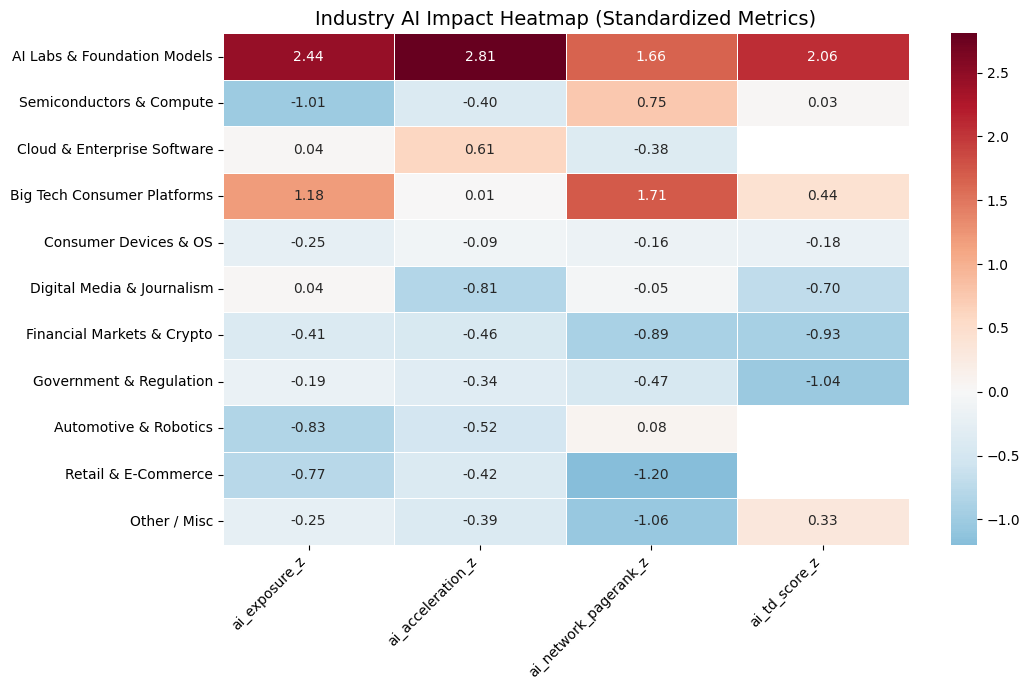

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = industry_impact.set_index("industry")[
    [m + "_z" for m in metrics]
]

plt.figure(figsize=(11, 7))

sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=heatmap_data.isna()
)

plt.title("Industry AI Impact Heatmap (Standardized Metrics)", fontsize=14)
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()